# Filtered surrogate scans

This notebook removes failed or numerically corrupted simulations
**before** fitting the surrogate. The same mask is applied to `Xs`,
`Ys`, `Ps`, `Ss`, and `index` whenever those arrays are sample-aligned.

It then refits the output scaler and trains the random-forest surrogate.
The notebook also includes outer-radius, DT ice-thickness, and
Be-thickness scans, with `Y_rhoRDT` explicitly plotted.

In [21]:
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import millefeuille as mf


# ------------------------------------------------------------------
# 1. Load the original state.
# ------------------------------------------------------------------
state_raw = mf.State.load(
    "databases/Gorgon_MF_DB_Gorgon_MF_iceburner_final_week.db"
)

# Work on a copy so the loaded state remains available for comparison.
state = copy.deepcopy(state_raw)


# ------------------------------------------------------------------
# 2. Identify invalid simulations before fitting.
# ------------------------------------------------------------------
Y_raw = np.asarray(state.Ys, dtype=float)
n_raw = len(Y_raw)

if Y_raw.ndim != 2:
    raise ValueError(
        f"Expected state.Ys to be two-dimensional, got {Y_raw.shape}."
    )

objective_names = list(state.Y_names)

required_objectives = [
    "Y_TDT",
    "Y_rhoRDT",
    "Y_minus_peak_IFAR",
]

missing_objectives = [
    name for name in required_objectives
    if name not in objective_names
]

if missing_objectives:
    raise ValueError(
        "Missing required objectives: "
        f"{missing_objectives}. "
        f"Available objectives: {objective_names}"
    )

tdt_idx = objective_names.index("Y_TDT")
rhor_idx = objective_names.index("Y_rhoRDT")
ifar_idx = objective_names.index("Y_minus_peak_IFAR")

# Recover the simulation IDs if state.index is sample-aligned.
state_index = getattr(state, "index", None)

if state_index is not None:
    candidate_ids = np.asarray(state_index).reshape(-1)
else:
    candidate_ids = np.arange(n_raw)

if len(candidate_ids) != n_raw:
    print(
        "state.index is not sample-aligned; "
        "using row positions as sample IDs."
    )
    candidate_ids = np.arange(n_raw)

# The four simulations already identified as invalid.
known_bad_ids = np.array([112, 113, 114, 115])

known_bad_mask = np.isin(
    candidate_ids,
    known_bad_ids,
)

# Very broad physical/numerical safety checks. These thresholds are
# deliberately loose and only reject obviously corrupted outputs.
finite_mask = np.isfinite(Y_raw).all(axis=1)

numerical_failure_mask = (
    (Y_raw[:, tdt_idx] <= 1.0e-12)
    | (Y_raw[:, rhor_idx] <= 0.0)
    | (Y_raw[:, rhor_idx] >= 1.0e6)
    | (Y_raw[:, ifar_idx] >= 0.0)
)

valid_mask = (
    finite_mask
    & ~known_bad_mask
    & ~numerical_failure_mask
)

removed_mask = ~valid_mask

removed_df = pd.DataFrame(
    Y_raw[removed_mask],
    columns=objective_names,
)
removed_df.insert(
    0,
    "sample_id",
    candidate_ids[removed_mask],
)

print(f"Original samples: {n_raw}")
print(f"Removed samples:  {removed_mask.sum()}")
print(f"Retained samples: {valid_mask.sum()}")

if len(removed_df):
    display(removed_df)
else:
    print("No invalid samples were detected.")


# ------------------------------------------------------------------
# 3. Apply the same mask to every sample-aligned state array.
# ------------------------------------------------------------------
def subset_sample_aligned_attribute(
    object_,
    attribute_name,
    mask,
):
    if not hasattr(object_, attribute_name):
        return False

    values = getattr(object_, attribute_name)

    if values is None:
        return False

    try:
        first_dimension = len(values)
    except TypeError:
        return False

    if first_dimension != len(mask):
        print(
            f"Not filtering {attribute_name}: "
            f"length {first_dimension} is not {len(mask)}."
        )
        return False

    row_positions = np.flatnonzero(mask)

    if hasattr(values, "iloc"):
        filtered_values = values.iloc[row_positions].copy()
    else:
        try:
            filtered_values = values[mask]
        except (TypeError, IndexError):
            filtered_values = np.asarray(values)[mask]

    setattr(
        object_,
        attribute_name,
        filtered_values,
    )
    return True


filtered_attributes = []

for attribute_name in [
    "Xs",
    "Ys",
    "Ps",
    "Ss",
    "index",
]:
    if subset_sample_aligned_attribute(
        state,
        attribute_name,
        valid_mask,
    ):
        filtered_attributes.append(attribute_name)

print(
    "Filtered state attributes:",
    filtered_attributes,
)

# Keep the stored sample count consistent when it is writable.
if hasattr(state, "nsamples"):
    try:
        state.nsamples = int(valid_mask.sum())
    except (AttributeError, TypeError):
        pass


# ------------------------------------------------------------------
# 4. Refit the output scaler, because the original scaler may have
#    been influenced by the corrupted objective values.
# ------------------------------------------------------------------
y_scaler = getattr(state, "Y_scaler", None)

if y_scaler is not None and hasattr(y_scaler, "fit"):
    y_scaler.fit(
        np.asarray(state.Ys, dtype=float)
    )
    print("Refitted state.Y_scaler on filtered outputs.")
else:
    print(
        "No refittable state.Y_scaler was found; "
        "the surrogate will use the filtered state as supplied."
    )


# Final consistency check.
n_filtered = len(state.Ys)

for attribute_name in ["Xs", "Ys"]:
    values = getattr(state, attribute_name)
    if len(values) != n_filtered:
        raise ValueError(
            f"{attribute_name} has {len(values)} rows, "
            f"but state.Ys has {n_filtered}."
        )


# ------------------------------------------------------------------
# 5. Fit only after cleaning.
# ------------------------------------------------------------------
surrogate = mf.MultiOutputRandomForestSurrogate(
    n_outputs=len(state.Y_names),
    verbose=True,
)

surrogate.fit(state)

Original samples: 504
Removed samples:  6
Retained samples: 498


,sample_id,Y_TDT,Y_rhoRDT,Y_minus_peak_IFAR,Y_minus_current
0,112.0,0.000000e+00,0.000000e+00,0.000000,-1.679127
1,113.0,6.218972e-84,4.117592e+130,-6.165904,-1.352298
2,114.0,1.026122e-135,9.821299e+181,-4.936679,-1.562321
3,115.0,5.225875e-25,3.570593e+70,-2.692311,-1.169968
4,185.0,4.619410e+03,-1.316964e+02,-8.761613,-1.239512
5,187.0,3.736836e+03,-1.363811e+02,-5.073990,-1.212700


Filtered state attributes: ['Xs', 'Ys', 'Ps', 'index']
Refitted state.Y_scaler on filtered outputs.


In [22]:
X_train = np.asarray(state.Xs, dtype=float)

print("Input names:")
for i, name in enumerate(state.X_names):
    print(f"  {i}: {name}")

print("\nObjective names:")
for i, name in enumerate(state.Y_names):
    print(f"  {i}: {name}")

print("\nTraining-data ranges:")
for i, name in enumerate(state.X_names):
    print(
        f"{name:20s}: "
        f"{np.nanmin(X_train[:, i]):.6g} to "
        f"{np.nanmax(X_train[:, i]):.6g}"
    )

Input names:
  0: f_laser
  1: f_R_outer
  2: f_Pi
  3: f_Be
  4: f_rho
  5: current

Objective names:
  0: Y_TDT
  1: Y_rhoRDT
  2: Y_minus_peak_IFAR
  3: Y_minus_current

Training-data ranges:
f_laser             : 0.500215 to 1.49814
f_R_outer           : 0.900548 to 1.09977
f_Pi                : 0.980037 to 1.01995
f_Be                : 0.501616 to 1.48861
f_rho               : 0.502473 to 1.49894
current             : 20.0086 to 59.8965


In [23]:
def find_name_index(names, search_text):
    matches = [
        i for i, name in enumerate(names)
        if search_text.lower() in str(name).lower()
    ]

    if not matches:
        raise ValueError(
            f"Could not find '{search_text}'. "
            f"Available names: {list(names)}"
        )

    if len(matches) > 1:
        print(
            f"Multiple matches for '{search_text}': "
            f"{[names[i] for i in matches]}. "
            f"Using {names[matches[0]]}."
        )

    return matches[0]


def unpack_prediction(prediction, n_points):
    if not isinstance(prediction, dict):
        raise TypeError(
            "Expected surrogate.predict(...) to return a dictionary, "
            f"but received {type(prediction)}."
        )

    Y_mean = np.asarray(prediction["mean"], dtype=float)
    Y_std = np.asarray(
        prediction.get("std", np.zeros_like(Y_mean)),
        dtype=float,
    )

    expected = (n_points, len(state.Y_names))
    transposed = (len(state.Y_names), n_points)

    if Y_mean.shape == transposed:
        Y_mean = Y_mean.T
    if Y_std.shape == transposed:
        Y_std = Y_std.T

    Y_mean = np.squeeze(Y_mean)
    Y_std = np.squeeze(Y_std)

    if Y_mean.shape != expected:
        raise ValueError(
            f"Mean prediction shape is {Y_mean.shape}; "
            f"expected {expected}."
        )

    if Y_std.shape != expected:
        raise ValueError(
            f"Standard-deviation shape is {Y_std.shape}; "
            f"expected {expected}."
        )

    return Y_mean, Y_std


def make_anchor():
    # A valid central design from the actual sampled data.
    return np.nanmedian(X_train, axis=0)


def plot_objective_predictions(
    x_values,
    Y_mean,
    Y_std,
    xlabel,
    title_prefix,
):
    objective_names = list(state.Y_names)

    rho_matches = [
        name for name in objective_names
        if "rhordt" in str(name).lower()
    ]
    print("rhoRDT objective match:", rho_matches)

    n_objectives = len(objective_names)

    fig, axes = plt.subplots(
        n_objectives,
        1,
        figsize=(8, 3.8 * n_objectives),
        squeeze=False,
    )
    axes = axes[:, 0]

    for j, name in enumerate(objective_names):
        mean = Y_mean[:, j]
        std = Y_std[:, j]

        finite = (
            np.isfinite(x_values)
            & np.isfinite(mean)
            & np.isfinite(std)
        )

        print(
            f"{name}: "
            f"{finite.sum()}/{len(x_values)} finite plotted points"
        )

        if finite.sum() == 0:
            axes[j].text(
                0.5,
                0.5,
                "No finite predictions",
                ha="center",
                va="center",
                transform=axes[j].transAxes,
            )
        else:
            order = np.argsort(x_values[finite])
            x_plot = x_values[finite][order]
            mean_plot = mean[finite][order]
            std_plot = std[finite][order]

            axes[j].plot(
                x_plot,
                mean_plot,
                linewidth=2,
                label="Surrogate mean",
            )
            axes[j].fill_between(
                x_plot,
                mean_plot - std_plot,
                mean_plot + std_plot,
                alpha=0.25,
                label="RF ensemble spread",
            )

        axes[j].set_xlabel(xlabel)
        axes[j].set_ylabel(str(name))
        axes[j].set_title(f"{title_prefix}: {name}")
        axes[j].grid(alpha=0.3)
        axes[j].legend(loc="best")

    plt.tight_layout()
    plt.show()


def scan_input(
    input_search_text,
    scan_min=None,
    scan_max=None,
    n_points=100,
    anchor=None,
    xlabel=None,
):
    input_index = find_name_index(
        state.X_names,
        input_search_text,
    )
    input_name = state.X_names[input_index]

    if anchor is None:
        anchor = make_anchor()

    anchor = np.asarray(anchor, dtype=float).copy()

    if scan_min is None:
        scan_min = np.nanpercentile(
            X_train[:, input_index],
            5,
        )

    if scan_max is None:
        scan_max = np.nanpercentile(
            X_train[:, input_index],
            95,
        )

    scan_values = np.linspace(
        scan_min,
        scan_max,
        n_points,
    )

    X_pred = np.repeat(
        anchor[None, :],
        n_points,
        axis=0,
    )
    X_pred[:, input_index] = scan_values

    prediction = surrogate.predict(state, X_pred)
    Y_mean, Y_std = unpack_prediction(
        prediction,
        n_points,
    )

    plot_objective_predictions(
        scan_values,
        Y_mean,
        Y_std,
        xlabel=xlabel or str(input_name),
        title_prefix=f"Scan of {input_name}",
    )

    return {
        "input_name": input_name,
        "scan_values": scan_values,
        "X_pred": X_pred,
        "Y_mean": Y_mean,
        "Y_std": Y_std,
        "anchor": anchor,
    }

## Outer-radius multiplier scan

rhoRDT objective match: ['Y_rhoRDT']
Y_TDT: 100/100 finite plotted points
Y_rhoRDT: 100/100 finite plotted points
Y_minus_peak_IFAR: 100/100 finite plotted points
Y_minus_current: 100/100 finite plotted points


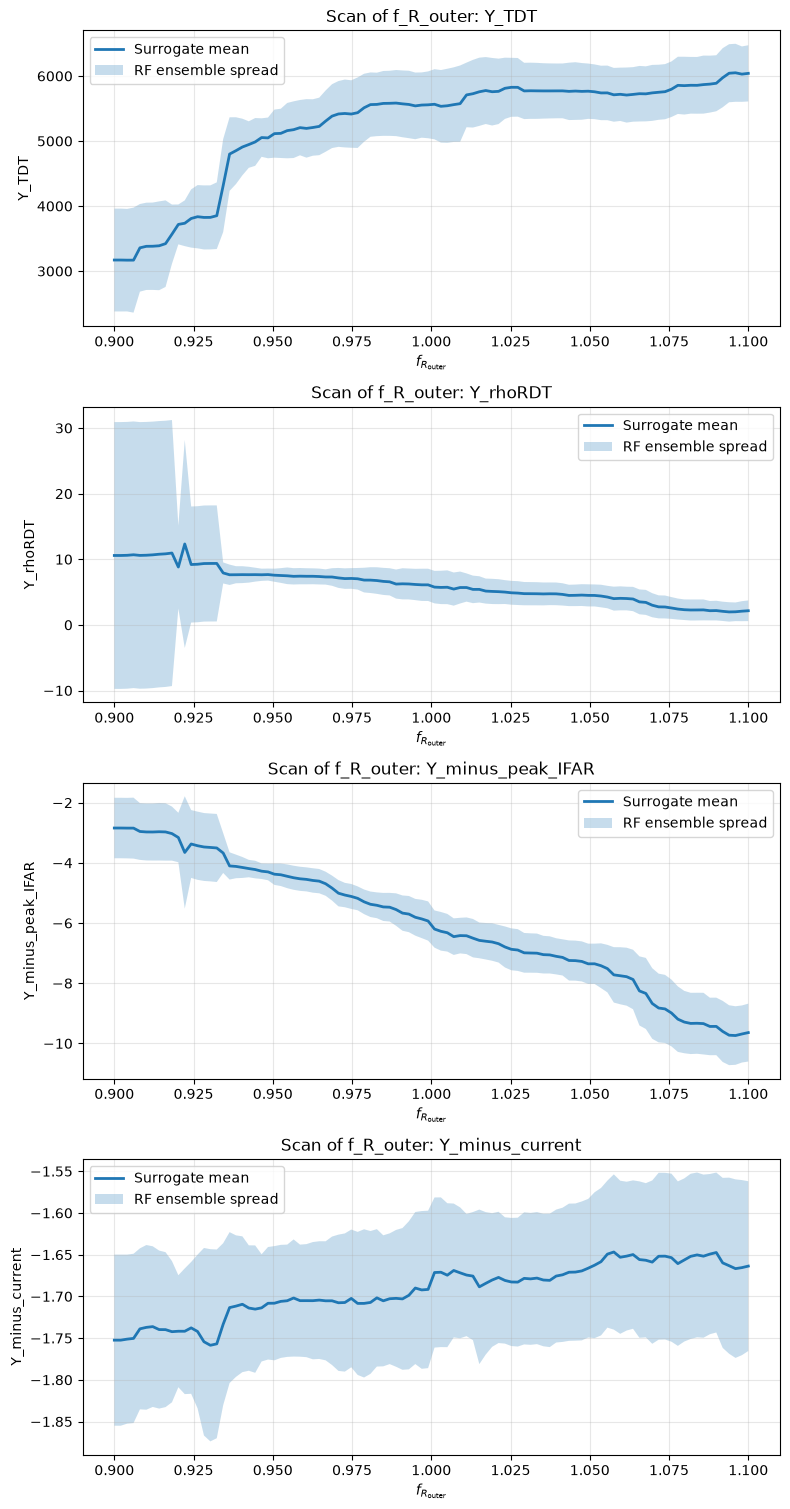

In [24]:
radius_scan = scan_input(
    input_search_text="R_outer",
    scan_min=0.9,
    scan_max=1.1,
    n_points=100,
    xlabel=r"$f_{R_{\mathrm{outer}}}$",
)

## DT ice-thickness scan

DT ice thickness is derived rather than stored directly as a surrogate input.
This scan varies `f_Pi`, computes the corresponding physical DT ice thickness,
and plots every objective against ice thickness.

Valid ice geometries: 100/100
rhoRDT objective match: ['Y_rhoRDT']
Y_TDT: 100/100 finite plotted points
Y_rhoRDT: 100/100 finite plotted points
Y_minus_peak_IFAR: 100/100 finite plotted points
Y_minus_current: 100/100 finite plotted points


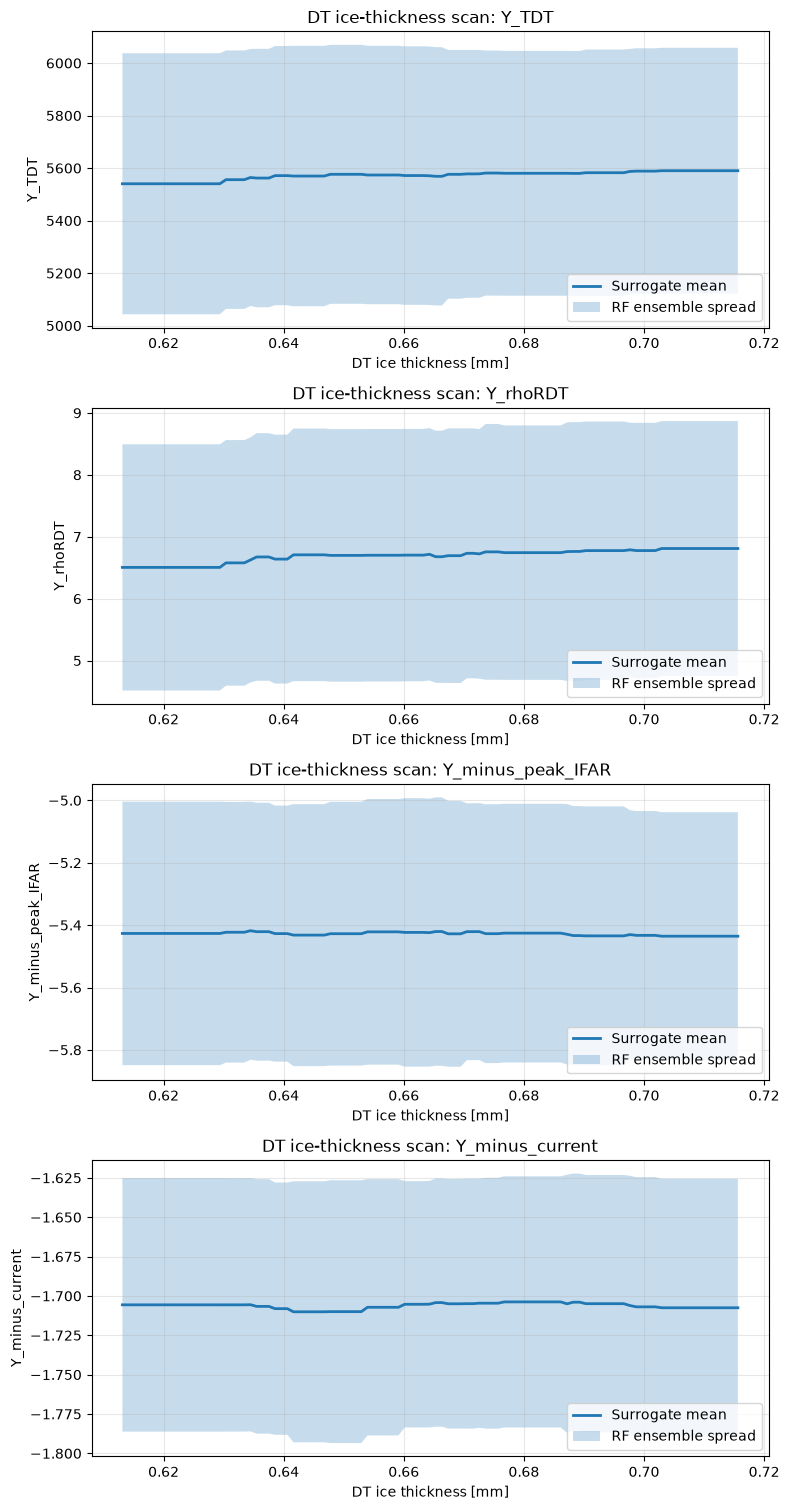

In [25]:
R_OUTER_20 = 2.79e-3
R_INNER_20 = 2.325e-3
PI_20 = 1.20e-7
RHO_BE = 1.85e3
RHO_ICE = 0.92e3


def physical_dt_ice_thickness(x_row):
    x_row = np.asarray(x_row, dtype=float)

    r_index = find_name_index(state.X_names, "R_outer")
    pi_index = find_name_index(state.X_names, "Pi")
    be_index = find_name_index(state.X_names, "Be")
    current_index = find_name_index(state.X_names, "current")

    f_r_outer = x_row[r_index]
    f_pi = x_row[pi_index]
    f_be = x_row[be_index]
    current_value = x_row[current_index]

    # Handles either physical current in MA or a current multiplier.
    training_current = X_train[:, current_index]
    if np.nanmax(training_current) <= 5:
        current_ma = 20.0 * current_value
    else:
        current_ma = current_value

    s = current_ma / 20.0

    r_outer_scaled = R_OUTER_20 * s**0.381
    r_inner_scaled = R_INNER_20 * s**0.206
    be_thickness_scaled = (
        r_outer_scaled - r_inner_scaled
    )
    pi_scaled = PI_20 * s**2

    r_outer = f_r_outer * r_outer_scaled
    be_thickness = f_be * be_thickness_scaled
    pi_parameter = f_pi * pi_scaled

    inner_be_radius = r_outer - be_thickness

    shell_mass_per_length = (
        pi_parameter / r_outer**2
    )

    be_mass_per_length = (
        np.pi
        * (r_outer**2 - inner_be_radius**2)
        * RHO_BE
    )

    ice_mass_per_length = (
        shell_mass_per_length
        - be_mass_per_length
    )

    if (
        r_outer <= 0
        or inner_be_radius <= 0
        or ice_mass_per_length <= 0
    ):
        return np.nan

    ice_inner_squared = (
        inner_be_radius**2
        - ice_mass_per_length
        / (np.pi * RHO_ICE)
    )

    if ice_inner_squared <= 0:
        return np.nan

    ice_inner_radius = np.sqrt(
        ice_inner_squared
    )

    return inner_be_radius - ice_inner_radius


def scan_dt_ice_thickness(
    pi_min=0.9,
    pi_max=1.1,
    n_points=100,
    anchor=None,
):
    pi_index = find_name_index(
        state.X_names,
        "Pi",
    )

    if anchor is None:
        anchor = make_anchor()

    anchor = np.asarray(
        anchor,
        dtype=float,
    ).copy()

    pi_scan = np.linspace(
        pi_min,
        pi_max,
        n_points,
    )

    X_pred = np.repeat(
        anchor[None, :],
        n_points,
        axis=0,
    )
    X_pred[:, pi_index] = pi_scan

    ice_thickness_mm = 1e3 * np.array([
        physical_dt_ice_thickness(row)
        for row in X_pred
    ])

    valid_geometry = np.isfinite(
        ice_thickness_mm
    )

    print(
        "Valid ice geometries: "
        f"{valid_geometry.sum()}/{n_points}"
    )

    prediction = surrogate.predict(
        state,
        X_pred,
    )
    Y_mean, Y_std = unpack_prediction(
        prediction,
        n_points,
    )

    x_for_plot = ice_thickness_mm.copy()
    x_for_plot[~valid_geometry] = np.nan

    plot_objective_predictions(
        x_for_plot,
        Y_mean,
        Y_std,
        xlabel="DT ice thickness [mm]",
        title_prefix="DT ice-thickness scan",
    )

    return {
        "pi_scan": pi_scan,
        "ice_thickness_mm": ice_thickness_mm,
        "valid_geometry": valid_geometry,
        "X_pred": X_pred,
        "Y_mean": Y_mean,
        "Y_std": Y_std,
        "anchor": anchor,
    }


ice_scan = scan_dt_ice_thickness(
    pi_min=0.98,
    pi_max=1.02,
    n_points=100,
)

## Optional Be-thickness scan

This scans the Be liner thickness, which is different from DT ice thickness.

rhoRDT objective match: ['Y_rhoRDT']
Y_TDT: 100/100 finite plotted points
Y_rhoRDT: 100/100 finite plotted points
Y_minus_peak_IFAR: 100/100 finite plotted points
Y_minus_current: 100/100 finite plotted points


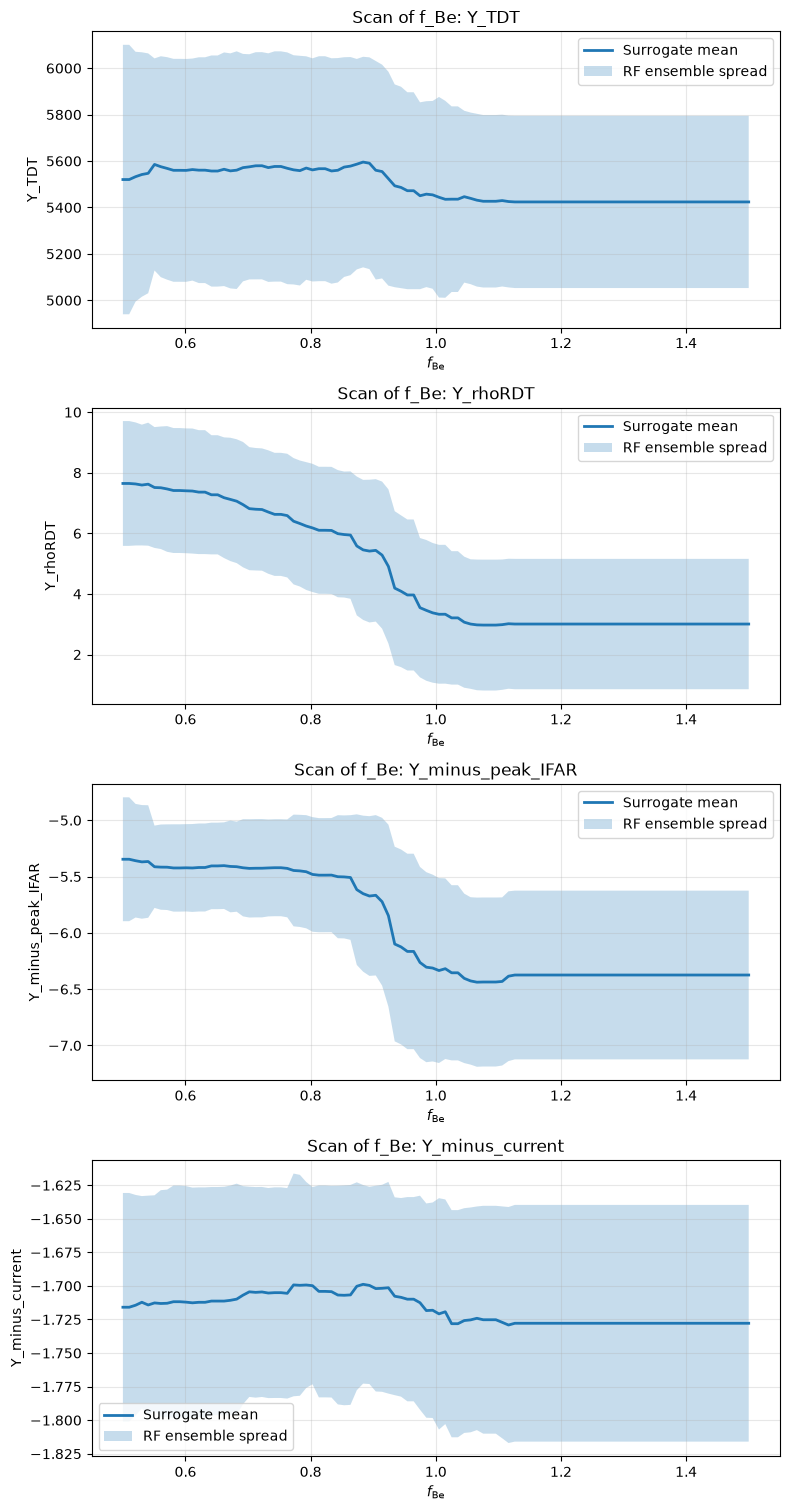

In [26]:
be_scan = scan_input(
    input_search_text="Be",
    scan_min=0.5,
    scan_max=1.5,
    n_points=100,
    xlabel=r"$f_{\mathrm{Be}}$",
)

In [27]:
# be_scan = scan_input(
#     input_search_text="f_laser",
#     scan_min=0.5,
#     scan_max=1.5,
#     n_points=100,
#     xlabel=r"$f_{\mathrm{f_laser}}$",
# )

rhoRDT objective match: ['Y_rhoRDT']
Y_TDT: 200/200 finite plotted points
Y_rhoRDT: 200/200 finite plotted points
Y_minus_peak_IFAR: 200/200 finite plotted points
Y_minus_current: 200/200 finite plotted points


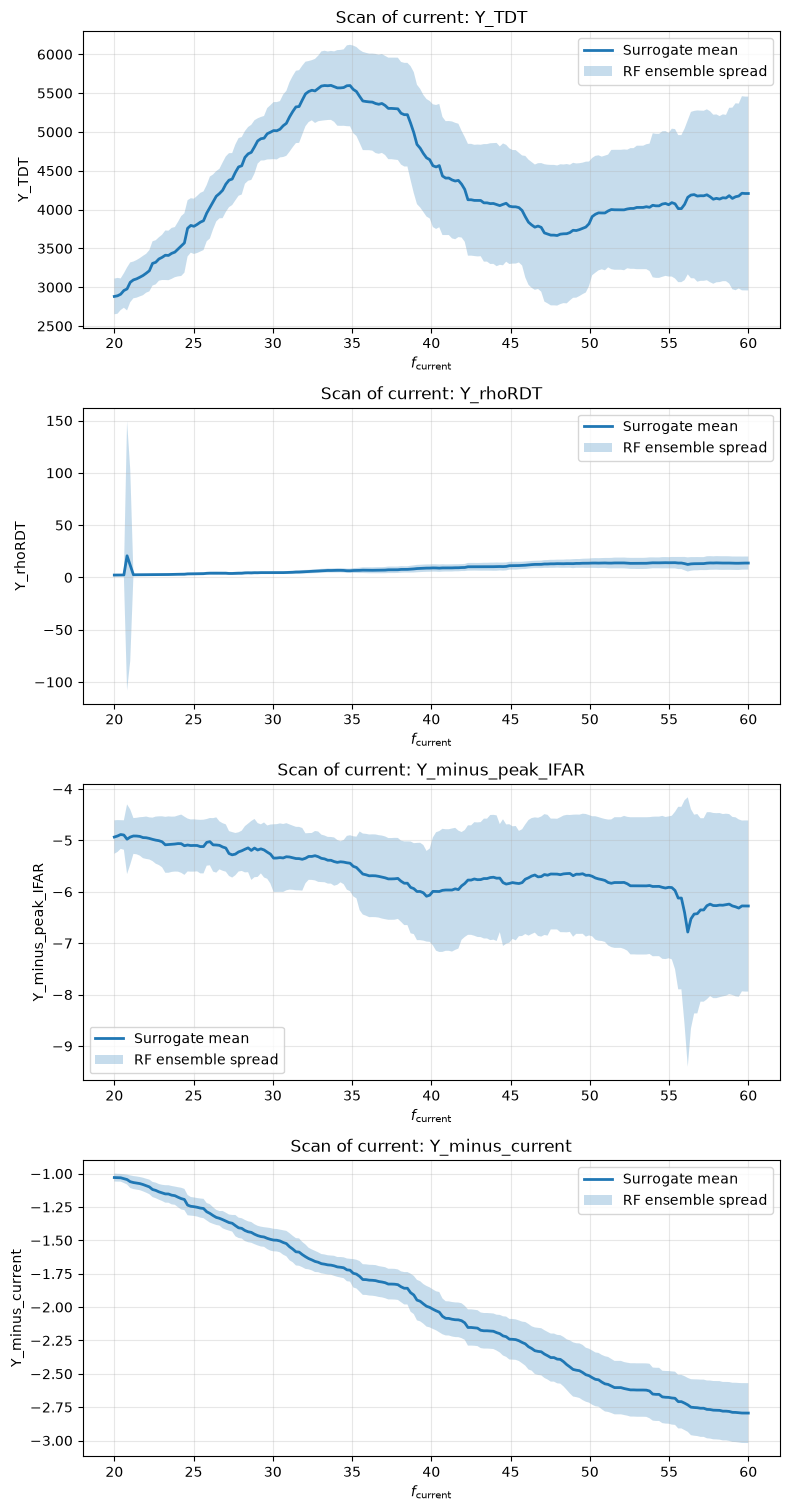

In [28]:
be_scan = scan_input(
    input_search_text="current",
    scan_min=20,
    scan_max=60,
    n_points=200,
    xlabel=r"$f_{\mathrm{current}}$",
)

rhoRDT objective match: ['Y_rhoRDT']
Y_TDT: 100/100 finite plotted points
Y_rhoRDT: 100/100 finite plotted points
Y_minus_peak_IFAR: 100/100 finite plotted points
Y_minus_current: 100/100 finite plotted points


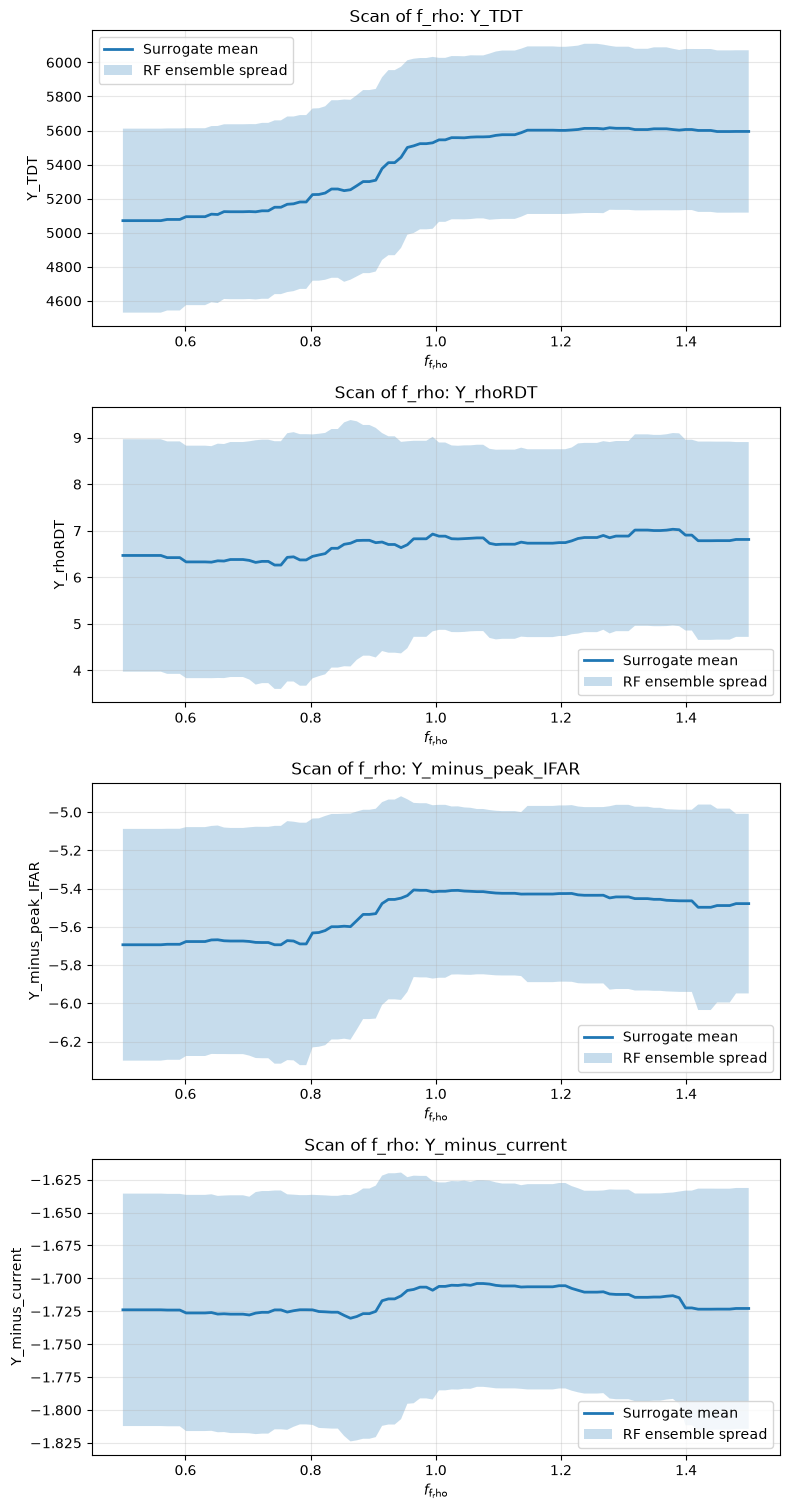

In [29]:
be_scan = scan_input(
    input_search_text="f_rho",
    scan_min=0.5,
    scan_max=1.5,
    n_points=100,
    xlabel=r"$f_{\mathrm{f_rho}}$",
)

rhoRDT objective match: ['Y_rhoRDT']
Y_TDT: 100/100 finite plotted points
Y_rhoRDT: 100/100 finite plotted points
Y_minus_peak_IFAR: 100/100 finite plotted points
Y_minus_current: 100/100 finite plotted points


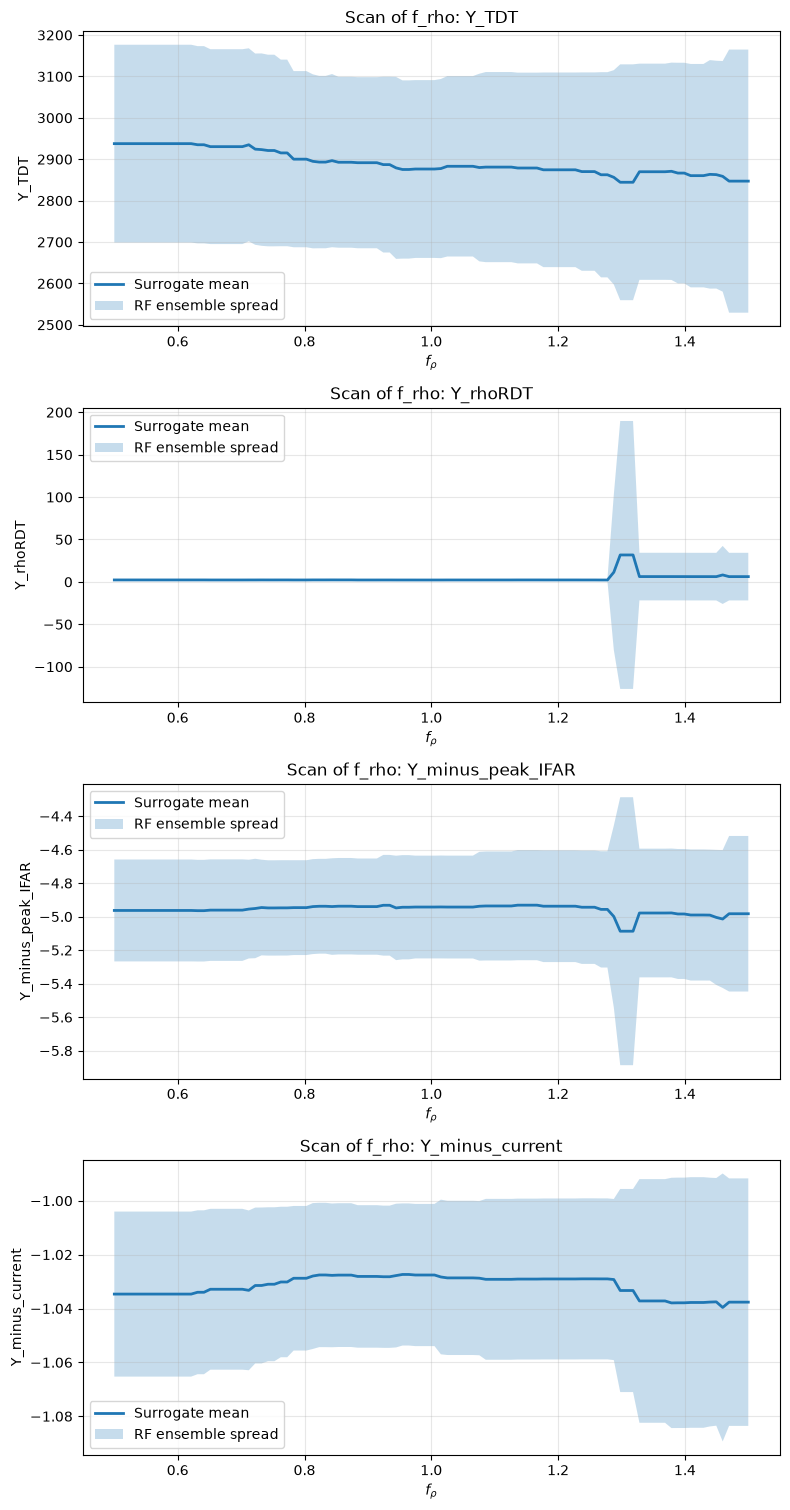

rhoRDT objective match: ['Y_rhoRDT']
Y_TDT: 100/100 finite plotted points
Y_rhoRDT: 100/100 finite plotted points
Y_minus_peak_IFAR: 100/100 finite plotted points
Y_minus_current: 100/100 finite plotted points


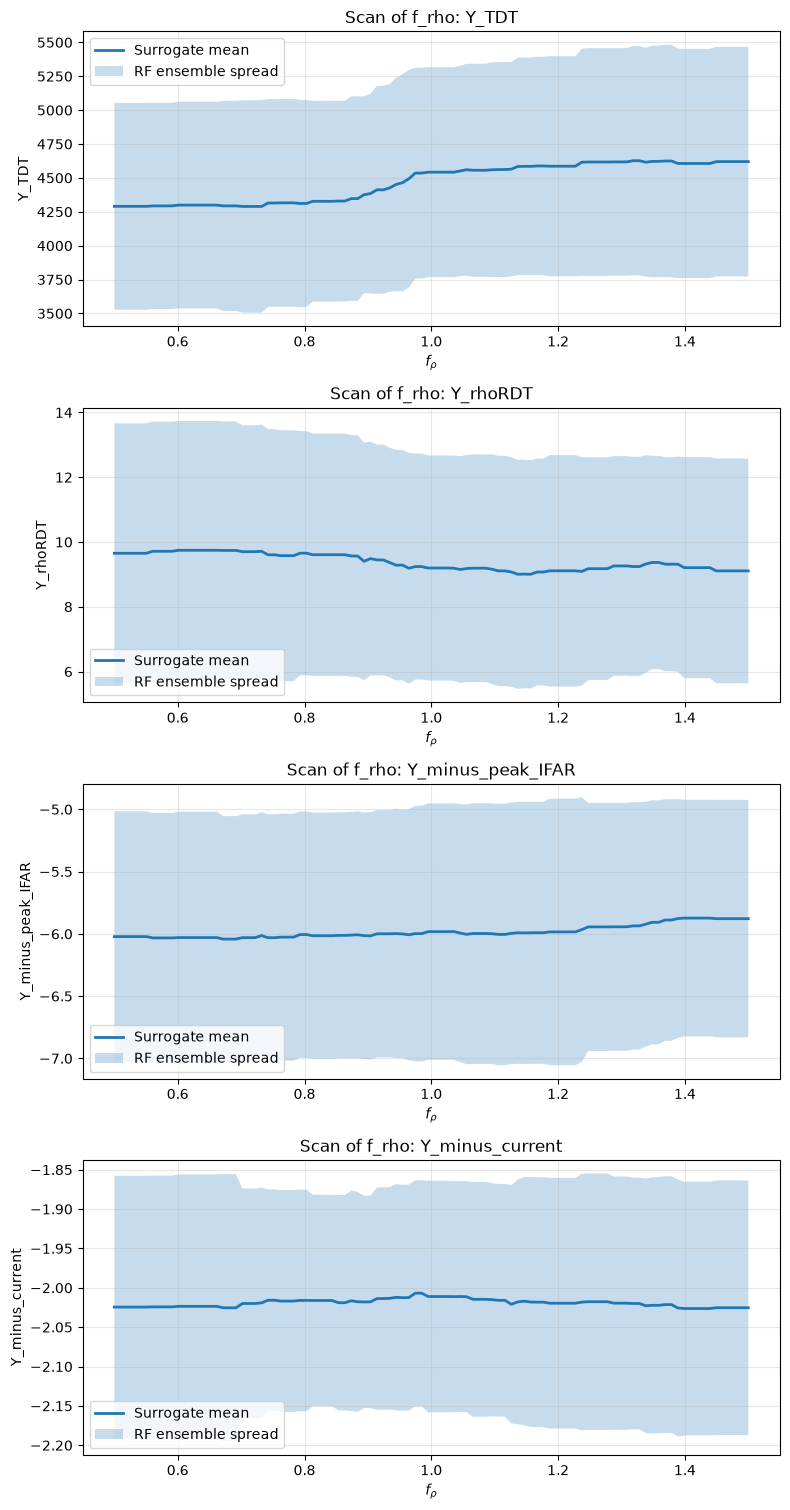

rhoRDT objective match: ['Y_rhoRDT']
Y_TDT: 100/100 finite plotted points
Y_rhoRDT: 100/100 finite plotted points
Y_minus_peak_IFAR: 100/100 finite plotted points
Y_minus_current: 100/100 finite plotted points


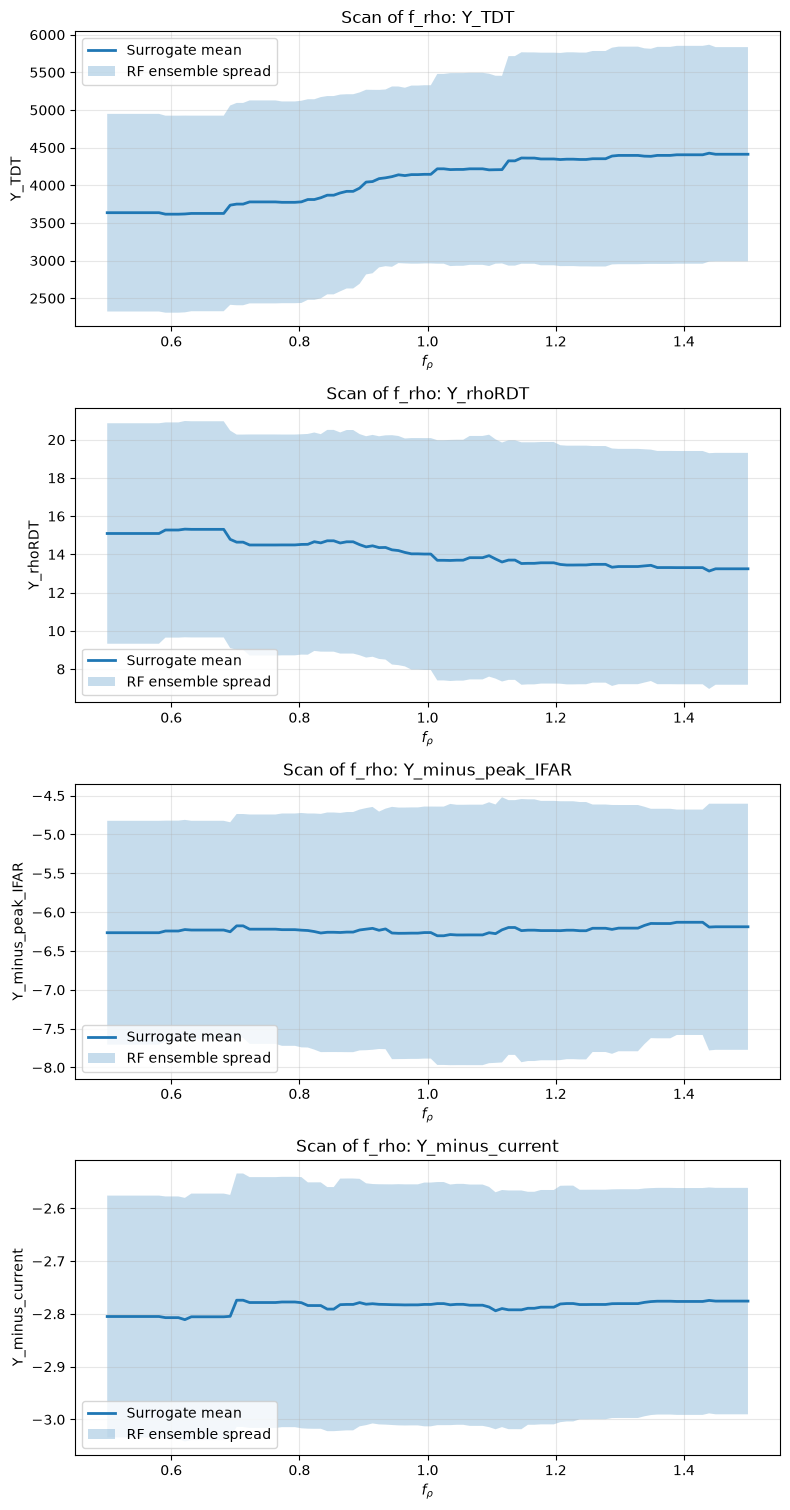

In [30]:
current_idx = find_name_index(state.X_names, "current")

for current_ma in [20, 40, 60]:
    anchor = make_anchor()
    anchor[current_idx] = current_ma

    scan_input(
        input_search_text="f_rho",
        scan_min=0.5,
        scan_max=1.5,
        n_points=100,
        anchor=anchor,
        xlabel=r"$f_{\rho}$",
    )